# Loss overview of the real-only baselines

One view of every training loss component of every analysed model: final, minimum and test values, and training-health flags. Its purpose is a fast check of the models before any pixel-level analysis.

## Introduction

The real-only baselines are trained with four objective terms: Masserstein reconstruction (weight 1.0),
variational PU loss of the molecular head (0.2), contractive Fisher-Rao spectral-hinge regularization
(2e-3) and InfoNCE peak-permutation contrast (1e-3). `total_loss` is their weighted sum. Every cell compares
model *groups* (one per spectral axis) with one point per repetition, so the same cells remain readable when
later campaign phases (pretraining, adaptation) are added as further groups.

### Assumptions

The trainer builds its validation and test data loaders from the phase configuration,
including `supervision_sampling` (positive : unlabelled = 1 : 1, drawn with replacement).
Every *recorded* validation and test value is therefore an estimate on a re-sampled,
class-balanced population, not the mean over the plain partition. Checkpoint selection
(`restore_best`) uses the same sampled validation loss.


        * Components are compared within an axis; their absolute values are not comparable across axes because the
          Masserstein cost scales with the transported m/z distance and the head has different class sets.

### Notation

* $L_{\mathrm{rec}}$: Masserstein; $L_{\mathrm{VPU}}$: `molecule_vpu__vpu`; $L_{\mathrm{con}}$: contractive;
  $L_{\mathrm{NCE}}$: `peak_permutation`; $L$: `total_loss`.
* Splits: `train` (epoch mean), `validation` and `test` (sampled, see assumptions).

## Configuration

### Scope

This notebook describes the real-only baselines. Since the full campaign run its tables contain all 310 models; `table` keeps the baseline rows only. The training histories of the pretraining lineages are in `part_0_05_synthetic_pretraining_curves` and `part_0_06_finetuning_curves`.

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "loss_overview"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


BASELINE_MODELS = catalog[catalog.role == settings["baseline_role"]]


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute, restricted to the real-only baselines.

    The table covers every campaign model; the pretraining lineages are analysed in parts 0_05 and 0_06.
    """
    frame = load_table(settings, ANALYSIS, name, AXIS)
    if "variant" in frame.columns:
        return frame[frame.variant == "baseline"]
    if "model_id" in frame.columns:
        return frame[frame.model_id.isin(BASELINE_MODELS.model_id)]
    if "display_label" in frame.columns:
        return frame[frame.display_label.isin(BASELINE_MODELS.display_label)]
    return frame


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(BASELINE_MODELS.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

COMPONENTS = ['masserstein', 'molecule_vpu__vpu', 'contractive', 'peak_permutation', 'total_loss']
SPLIT_COLORS = {'train': theme.model_palette[0], 'validation': theme.model_palette[2], 'test': theme.model_palette[3]}

Analysis: loss_overview | axis: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`loss_overview` reads `history.json` of every selected model; no inference is involved.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis loss_overview > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Final, minimum and test value of every component

### Methodology

#### Theoretical

For every model and component the value at the last epoch, the minimum over epochs and the test value of the
restored checkpoint are compared. A large gap between final and minimum validation values indicates
instability late in training; a large gap between train and validation values indicates overfitting.

#### Implementation

`final_losses` holds one row per model, component and split. The figure shows the final value for
train/validation and the recorded test value per repetition.

#### Figure descriptions

One panel per component; x = model group, colour = split, one point per repetition, horizontal bar = mean
over repetitions. Lower is better for every component (the VPU loss is negative by construction).

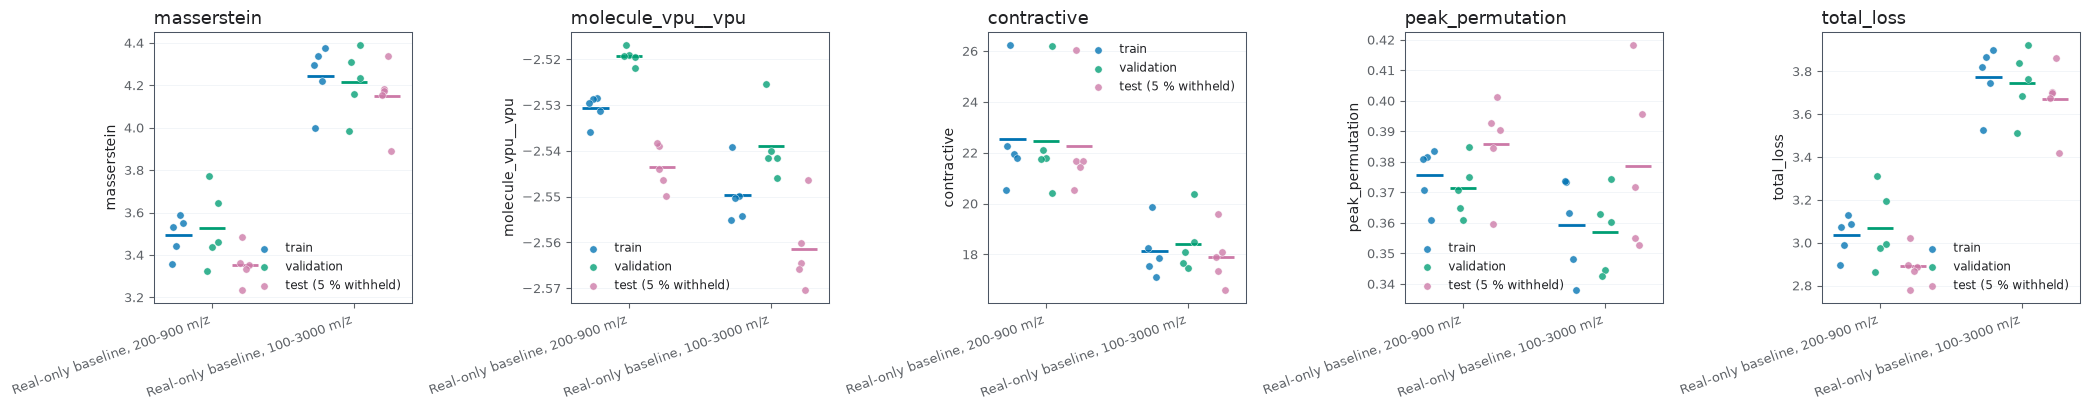

In [3]:
final = table('final_losses')
final_long = pd.concat([final[final.split != 'test'].assign(value=final.final_value), final[final.split == 'train'].assign(split='test', value=final.test_value)])
figure, axes = plt.subplots(1, len(COMPONENTS), figsize=(4.2 * len(COMPONENTS), 4.2), dpi=theme.figure_dpi)
for ax, component in zip(axes, COMPONENTS):
    figures.repetition_points(final_long[final_long.component == component], value='value', group='display_label', hue='split', order=LABELS, hue_order=['train', 'validation', 'test'], colors=SPLIT_COLORS, ylabel=component, title=component, ax=ax, theme=theme)
figure.tight_layout()

In [4]:
display(table('group_summary').pivot_table(index=['display_label', 'split'], columns='component', values='mean'))

component                                    contractive  masserstein  molecule_vpu__vpu  peak_permutation  total_loss
display_label                    split                                                                                
Real-only baseline, 100-3000 m/z train           18.1339       4.2450            -2.5497            0.3594      3.7716
                                 validation      18.4180       4.2155            -2.5389            0.3569      3.7449
Real-only baseline, 200-900 m/z  train           22.5580       3.4952            -2.5307            0.3755      3.0345
                                 validation      22.4486       3.5273            -2.5193            0.3714      3.0687

### Remarks

- Train and (sampled) validation values are close for every component on both axes; no sign of overfitting at the component level.
- Absolute component values differ between axes as expected (longer transport on the wide axis; different class sets).

### Notes

## Training-health flags

### Methodology

#### Theoretical

A model is healthy when it completed its epochs without non-finite values, when the restored checkpoint is
its best validation epoch and when the validation loss did not rise markedly after its minimum.

#### Implementation

`validation_increase_after_minimum` flags a final validation total loss more than 5 % above its minimum;
`restored_epoch` is the last epoch flagged `is_best`; durations are summed epoch wall times.

#### Figure descriptions

No figure; one row per model.

In [5]:
display(table('training_health').drop(columns=['model_id', 'model_alias']))

,display_label,axis,repetition,variant,stage,phase,phase_index,epochs,restored_epoch,non_finite_values,total_duration_seconds,validation_total_final,validation_total_minimum,validation_increase_after_minimum,test_evaluated
0,"Real-only baseline, 200-900 m/z",axis-200-900,0,baseline,real_only,real_only,0,10,10,0,1396.8431,2.9756,2.9756,False,True
1,"Real-only baseline, 200-900 m/z",axis-200-900,1,baseline,real_only,real_only,0,10,8,0,4749.4924,3.1961,2.7631,True,True
2,"Real-only baseline, 200-900 m/z",axis-200-900,2,baseline,real_only,real_only,0,10,10,0,1360.9015,2.8625,2.8625,False,True
3,"Real-only baseline, 200-900 m/z",axis-200-900,3,baseline,real_only,real_only,0,10,8,0,1395.9295,2.9959,2.8445,True,True
4,"Real-only baseline, 200-900 m/z",axis-200-900,4,baseline,real_only,real_only,0,10,9,0,1396.3743,3.3135,2.8630,True,True
5,"Real-only baseline, 100-3000 m/z",axis-100-3000,0,baseline,real_only,real_only,0,10,10,0,1462.4523,3.6856,3.6856,False,True
6,"Real-only baseline, 100-3000 m/z",axis-100-3000,1,baseline,real_only,real_only,0,10,9,0,1327.7069,3.9247,3.6997,True,True
7,"Real-only baseline, 100-3000 m/z",axis-100-3000,2,baseline,real_only,real_only,0,10,8,0,1481.8772,3.5133,3.3689,False,True
8,"Real-only baseline, 100-3000 m/z",axis-100-3000,3,baseline,real_only,real_only,0,10,9,0,1628.5731,3.7634,3.6671,False,True
9,"Real-only baseline, 100-3000 m/z",axis-100-3000,4,baseline,real_only,real_only,0,10,10,0,1401.7303,3.8378,3.8378,False,True


### Remarks

- No non-finite values. The restored checkpoint is epoch 8-10; 3 of 5 narrow models and 1 of 5 wide models end more than 5 % above their best validation total loss (restored checkpoint is used for evaluation).
- Repetition 1 of the 200-900 axis took 3.4x longer per epoch (compute environment, not optimisation).

### Notes

## Results / Summary

### LLM

- **Observed:** all ten baselines trained without numerical problems; final train and validation values agree within repetition spread for every component.
- **Observed:** best checkpoints fall in epochs 8-10; four models end with a validation loss >5 % above their minimum, which `restore_best` removes.
- **Caveat:** validation/test values are supervision-sampled estimates (see `part_0_02`); comparisons between models are valid, absolute values are biased relative to plain means.
- **Implication:** the loss curves give no reason to exclude a model; the pixel-level notebooks use all five repetitions per axis.

### Person